In [1]:
%load_ext autoreload
%autoreload 2

In [4]:
# Import statements:
import sys
import os
import yaml
sys.path.append(os.getcwd() + '/../Client_modules/')

from mTempControl import *
import mResSweepDouble
from socProxy import makeProxy
import h5py
from PythonDrivers.control_atten import setatten
from getInputDicts import *
from getSweepTime import *
import time
import datetime
from run_power_sweep import run_power_sweep
from PythonDrivers.ldausbcli import CLI_Vaunix_Attn

# tempPath = os.path.join('Z:','t1Team','logFiles')

In [5]:
# Instantiate RFSoC
soc,soccfg=makeProxy('192.168.1.11')
print(soccfg)

Pyro.NameServer PYRO:Pyro.NameServer@192.168.1.11:8888
myqick PYRO:obj_73d19b493f334b6d878bb266f6b69f30@192.168.1.11:43133

QICK configuration:

	Board: ZCU216

	Global clocks (MHz): tProcessor 430.080, RF reference 245.760

	7 signal generator channels:
	0:	axis_signal_gen_v4 - tProc output 1, envelope memory 65536 samples
		DAC tile 2, ch 0, 32-bit DDS, fabric=430.080 MHz, fs=6881.280 MHz
	1:	axis_signal_gen_v4 - tProc output 2, envelope memory 65536 samples
		DAC tile 2, ch 1, 32-bit DDS, fabric=430.080 MHz, fs=6881.280 MHz
	2:	axis_signal_gen_v4 - tProc output 3, envelope memory 65536 samples
		DAC tile 2, ch 2, 32-bit DDS, fabric=430.080 MHz, fs=6881.280 MHz
	3:	axis_signal_gen_v4 - tProc output 4, envelope memory 65536 samples
		DAC tile 2, ch 3, 32-bit DDS, fabric=430.080 MHz, fs=6881.280 MHz
	4:	axis_signal_gen_v4 - tProc output 5, envelope memory 65536 samples
		DAC tile 3, ch 0, 32-bit DDS, fabric=430.080 MHz, fs=6881.280 MHz
	5:	axis_signal_gen_v4 - tProc output 6, envelope 

# Read in sweep parameters

In [7]:
print(os.getcwd())

c:\Users\my\Documents\GitHub\HouckLab_QICK\WorkingProjects\QM_Team\resonator_measurements\template_notebooks


In [8]:
# Read in sweep initial confirguration from yaml file
setup_file_name='2024-04-19_cooldown_setup.yaml'
setup_file_location = os.path.join('..','power_sweep','setup_files',setup_file_name)
dBm_lookup_file=r'C:\Users\my\Documents\GitHub\ZCU216\res_dev\dBm_lookup\11_atten-channel-2_rack-setup_2024-03-08.npz'
channel_number = 2

stream = open(setup_file_location, 'r')
setupDict = yaml.full_load(stream)
stream.close()

# select which chip to measure
chipDict = setupDict['2024-04-15_TAHP02_Al2O3_Ta-Au-300nm_01']
printSweepTime(chipDict,dBm_lookup_file)

Time per sweep (2 resonators): 760.8 min


# Take measurements

Time per sweep (2 resonators): 760.8 min
Frequencies out are: [5951.7] MHz


  0%|          | 0/1 [00:00<?, ?it/s]

Final time = 11.033 s
Frequencies out are: [5951.7] MHz


  0%|          | 0/20 [00:00<?, ?it/s]

Final time = 221.782 s


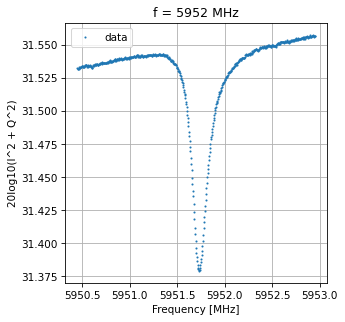

Saving data_p[-12.26738005]-2024-05-06-14-58-36
Frequencies out are: [5951.7] MHz


  0%|          | 0/50 [00:00<?, ?it/s]

Final time = 555.399 s


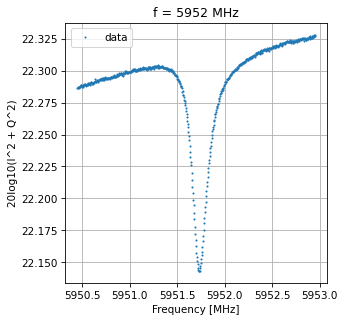

Saving data_p[-22.26738005]-2024-05-06-15-02-20
Frequencies out are: [5951.7] MHz


  0%|          | 0/100 [00:00<?, ?it/s]

Final time = 1110.465 s


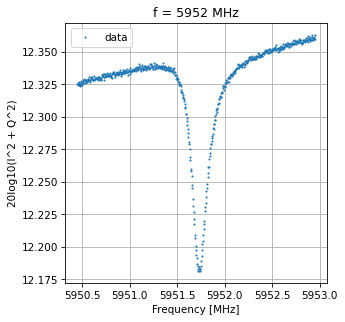

Saving data_p[-32.26738005]-2024-05-06-15-11-37
Frequencies out are: [5951.7] MHz


  0%|          | 0/200 [00:00<?, ?it/s]

Final time = 2221.783 s


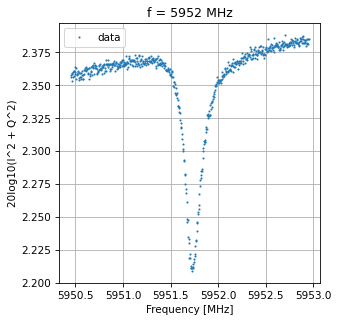

Saving data_p[-42.26738005]-2024-05-06-15-30-11
Frequencies out are: [5951.7] MHz


  0%|          | 0/400 [00:00<?, ?it/s]

Final time = 4421.241 s


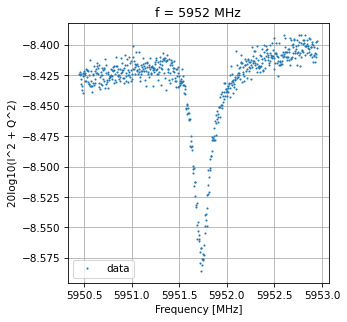

Saving data_p[-52.26738005]-2024-05-06-16-07-15
Frequencies out are: [5951.7] MHz


  0%|          | 0/800 [00:00<?, ?it/s]

Final time = 8888.863 s


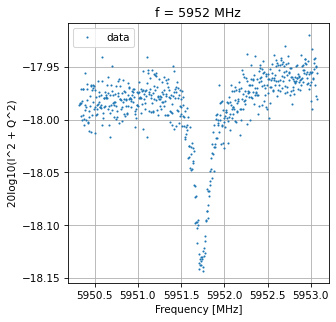

Saving data_p[-62.26738005]-2024-05-06-17-20-58
Frequencies out are: [5951.7] MHz


  0%|          | 0/1600 [00:00<?, ?it/s]

Final time = 17793.978 s


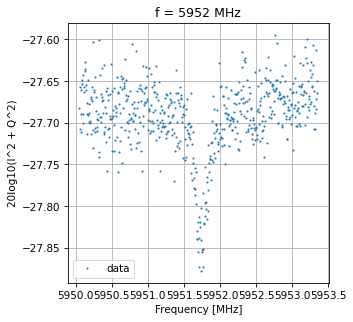

Saving data_p[-72.26738005]-2024-05-06-19-49-09
Time for measurement:
9:47:23.434381


In [9]:
time.sleep(60*60)
start_time = time.time()
run_power_sweep(soc,soccfg,chipDict,dBm_lookup_file,channel_number)
end_time = time.time()
print('Time for measurement:')
print(datetime.timedelta(seconds=end_time-start_time))

# Testing stuff

In [12]:
attobj = CLI_Vaunix_Attn()
attobj.set_attenuation(1,0,1)

True

In [13]:
# define sweep params


inputDict = {}
inputDict['LO_f'] = 0  # local oscillator frequency

# define frequencies
inputDict['span_f'] = [.03, .03]

# center freqs

inputDict['res_f']=[5946.61,6252.381]
inputDict['names']=['4p42',
  '4p70']
# define numbers of points
inputDict['n_expts'] = 500  # number of points along the frequency axis
inputDict['n_rounds'] = 1 # number of times to sweep along the frequency axis
inputDict['n_reps'] = 1  # number of repetitions to take at each frequency point
# inputDict['n_reps'] = 1

# timing. Units are clock cycles, but converted from us
inputDict['ring_up_time'] = 500  # time waiting for the resonator to ring up at the start of each sweep
inputDict['ring_between_time'] = 50  # time waiting for the resonator to ring up at the start of each sweep
inputDict['readout_length'] = 10000  # time to average over
inputDict['adc_trig_offset'] = 0.1  # time after the DAC starts the final steady pulse before the ADC starts it's read

# power
# idxs = [np.argmin(np.abs(np.array(f)-inputDict['res_f'][0])),np.argmin(np.abs(np.array(f)-inputDict['res_f'][1]))]
inputDict['basePowers'] = [0,0] # dBm
inputDict['gain'] = [30000, 30000]

In [9]:
savePath = r'Z:\t1Team\Data\2023-06-29_cooldown\kevin_LE_PRX_reviewer\RFSOC'

In [15]:
# acquire data
# Acquire
inputDict['power'] = inputDict['basePowers']
Instance2 = mResSweepDouble.ResSweep(path=savePath, prefix='phase_test', inputDict=inputDict, soc=soc, soccfg=soccfg)
data2 = mResSweepDouble.ResSweep.acquire(Instance2)
mResSweepDouble.ResSweep.display(Instance2, data2, fit=False)
# mResSweepDouble.ResSweep.save_data(Instance2, data2)

Frequencies out are: [5946.61, 6252.381] MHz


C:\Users\my\Documents\GitHub\ZCU216\res_dev\2023-10-19_cooldown\power-sweeps/../../Client_modules\mResSweepDouble.py:266: UserWarning: Temperature log is 22738.8 minutes out of date. Make sure you are outputting the log file from the temperature PC
  warnings.warn(


  0%|          | 0/1 [00:00<?, ?it/s]

With the given readout length there is a possibility that the sum buffer will overflow giving invalid results.
With the given readout length there is a possibility that the sum buffer will overflow giving invalid results.
With the given readout length there is a possibility that the sum buffer will overflow giving invalid results.
With the given readout length there is a possibility that the sum buffer will overflow giving invalid results.
With the given readout length there is a possibility that the sum buffer will overflow giving invalid results.
With the given readout length there is a possibility that the sum buffer will overflow giving invalid results.
With the given readout length there is a possibility that the sum buffer will overflow giving invalid results.
With the given readout length there is a possibility that the sum buffer will overflow giving invalid results.
With the given readout length there is a possibility that the sum buffer will overflow giving invalid results.
W

With the given readout length there is a possibility that the sum buffer will overflow giving invalid results.
With the given readout length there is a possibility that the sum buffer will overflow giving invalid results.
With the given readout length there is a possibility that the sum buffer will overflow giving invalid results.
With the given readout length there is a possibility that the sum buffer will overflow giving invalid results.
With the given readout length there is a possibility that the sum buffer will overflow giving invalid results.
With the given readout length there is a possibility that the sum buffer will overflow giving invalid results.
With the given readout length there is a possibility that the sum buffer will overflow giving invalid results.
With the given readout length there is a possibility that the sum buffer will overflow giving invalid results.
With the given readout length there is a possibility that the sum buffer will overflow giving invalid results.
W

With the given readout length there is a possibility that the sum buffer will overflow giving invalid results.
With the given readout length there is a possibility that the sum buffer will overflow giving invalid results.
With the given readout length there is a possibility that the sum buffer will overflow giving invalid results.
With the given readout length there is a possibility that the sum buffer will overflow giving invalid results.
With the given readout length there is a possibility that the sum buffer will overflow giving invalid results.
With the given readout length there is a possibility that the sum buffer will overflow giving invalid results.
With the given readout length there is a possibility that the sum buffer will overflow giving invalid results.
With the given readout length there is a possibility that the sum buffer will overflow giving invalid results.
With the given readout length there is a possibility that the sum buffer will overflow giving invalid results.
W

With the given readout length there is a possibility that the sum buffer will overflow giving invalid results.
With the given readout length there is a possibility that the sum buffer will overflow giving invalid results.
With the given readout length there is a possibility that the sum buffer will overflow giving invalid results.
With the given readout length there is a possibility that the sum buffer will overflow giving invalid results.
With the given readout length there is a possibility that the sum buffer will overflow giving invalid results.
With the given readout length there is a possibility that the sum buffer will overflow giving invalid results.
With the given readout length there is a possibility that the sum buffer will overflow giving invalid results.
With the given readout length there is a possibility that the sum buffer will overflow giving invalid results.
With the given readout length there is a possibility that the sum buffer will overflow giving invalid results.
W

With the given readout length there is a possibility that the sum buffer will overflow giving invalid results.
With the given readout length there is a possibility that the sum buffer will overflow giving invalid results.
With the given readout length there is a possibility that the sum buffer will overflow giving invalid results.
With the given readout length there is a possibility that the sum buffer will overflow giving invalid results.
With the given readout length there is a possibility that the sum buffer will overflow giving invalid results.
With the given readout length there is a possibility that the sum buffer will overflow giving invalid results.
With the given readout length there is a possibility that the sum buffer will overflow giving invalid results.
With the given readout length there is a possibility that the sum buffer will overflow giving invalid results.
With the given readout length there is a possibility that the sum buffer will overflow giving invalid results.
W

KeyboardInterrupt: 